# Decision Tree Classification on Heart Disease Dataset

## Assignment: Decision Tree Classification

### Objective
The objective of this project is to apply Decision Tree Classification to predict the presence of heart disease based on patient health attributes.

### Dataset
heart_disease.xlsx

### Target Variable
num

# Problem Statement

Heart disease is one of the leading causes of death worldwide. Early prediction can help healthcare professionals provide timely treatment and reduce health risks.

The goal of this project is to build a Decision Tree Classification model that predicts heart disease using patient medical information.

# Import Required Libraries

In [1]:
# Data Handling

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# Preprocessing

from sklearn.preprocessing import LabelEncoder

# Evaluation Metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# Ignore warnings

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
# Load Heart Disease Dataset

df = pd.read_excel("heart_disease.xlsx",
                   sheet_name="Heart_disease")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


# Exploratory Data Analysis (EDA)

In [3]:
# Dataset Shape

print("Rows and Columns :", df.shape)

Rows and Columns : (908, 13)


In [4]:
# Column Names

df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [5]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
# Statistical Summary

df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [7]:
# Missing Values

df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [8]:
# Fill Missing Values in oldpeak column

df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [9]:
# Check Missing Values Again

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

# Missing Value Treatment

The 'oldpeak' column contained missing values. These missing values were replaced using the median value of the column to avoid data loss and maintain data quality.

In [10]:
# Duplicate Values

df.duplicated().sum()

np.int64(1)

# Histogram

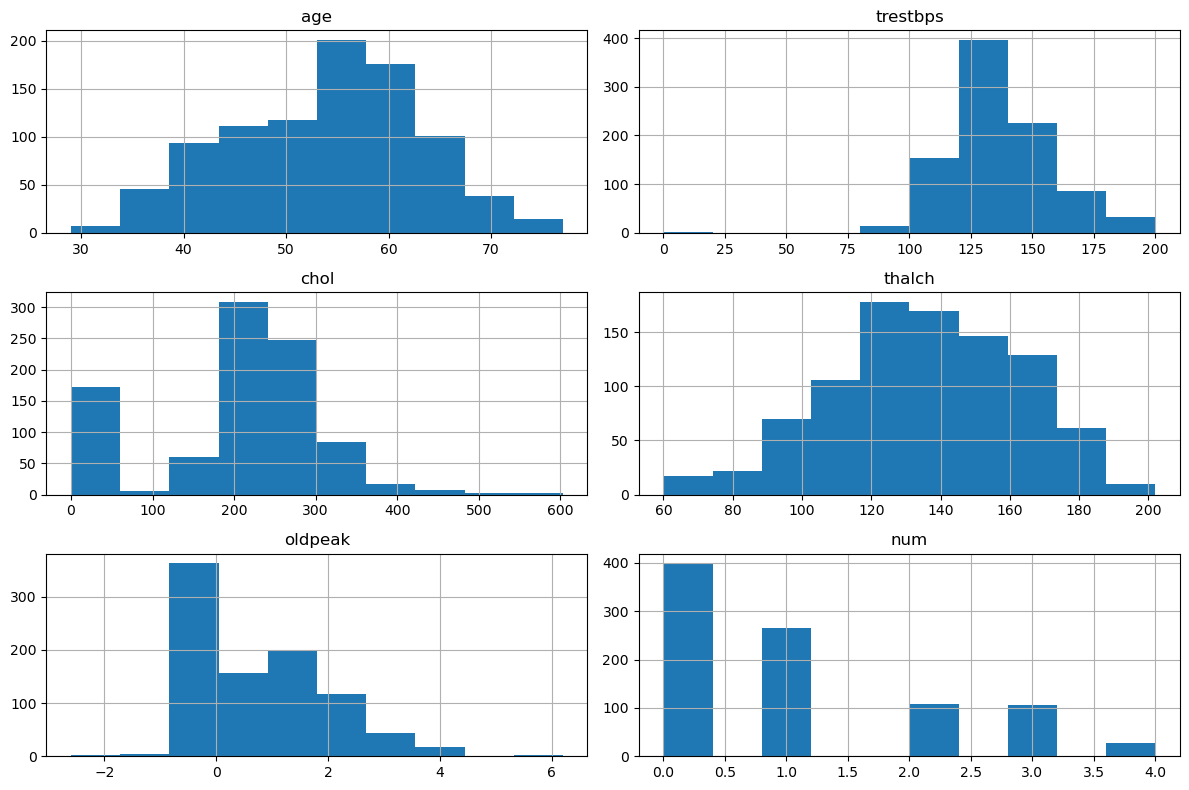

In [11]:
df.hist(figsize=(12,8))

plt.tight_layout()
plt.show()

# Boxplot

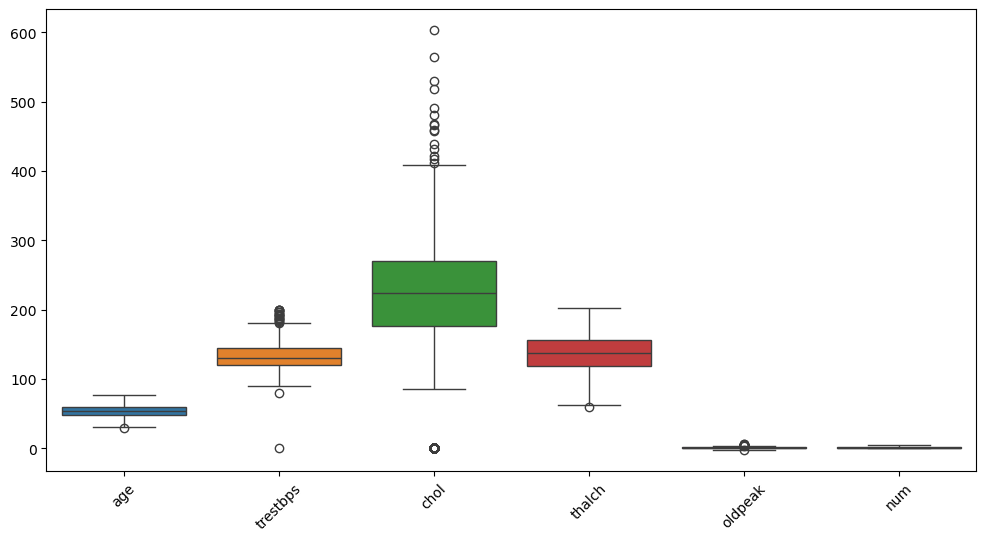

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df.select_dtypes(include=np.number))

plt.xticks(rotation=45)

plt.show()

# Correlation Analysis

In [13]:
corr = df.select_dtypes(include=np.number).corr()

corr

,age,trestbps,chol,thalch,oldpeak,num
age,1.000000,0.253999,-0.099967,-0.328088,0.217942,0.326493
trestbps,0.253999,1.000000,0.117488,-0.133360,0.134945,0.137251
chol,-0.099967,0.117488,1.000000,0.197907,0.032205,-0.238813
thalch,-0.328088,-0.133360,0.197907,1.000000,-0.112624,-0.323058
oldpeak,0.217942,0.134945,0.032205,-0.112624,1.000000,0.406078
num,0.326493,0.137251,-0.238813,-0.323058,0.406078,1.000000


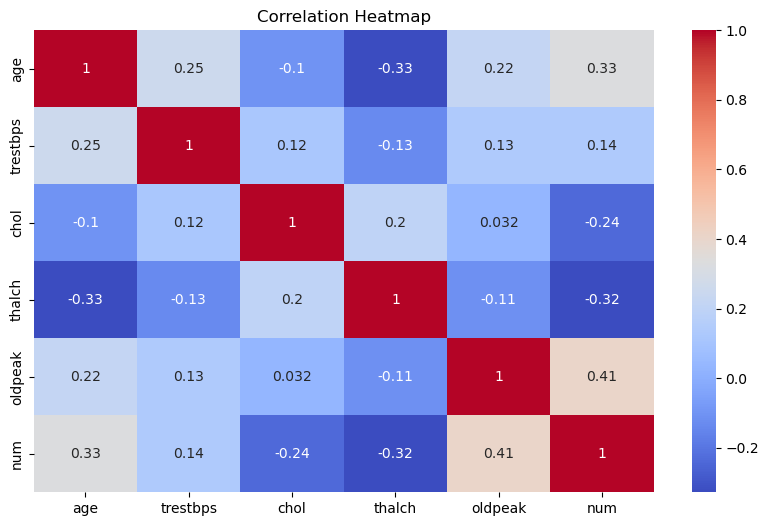

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

# Target Variable Distribution

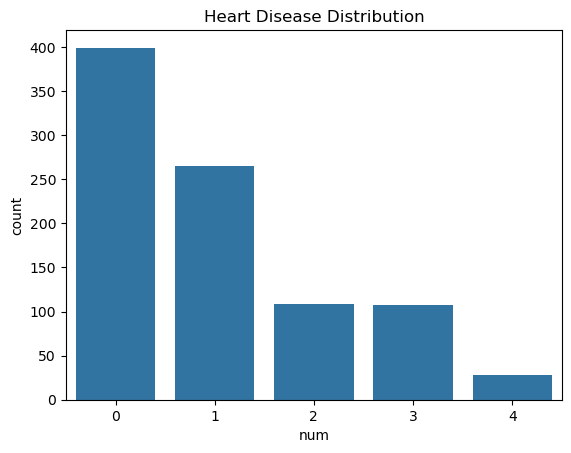

In [15]:
sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")

plt.show()

# Feature Engineering

Decision Tree requires numerical data.

Categorical variables are converted into numerical format using Label Encoding.

In [16]:
# Create Copy of Dataset

data = df.copy()

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [17]:
# Check Categorical Columns

data.select_dtypes(include='object').columns

Index(['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

In [18]:
# Import LabelEncoder

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder Object

le = LabelEncoder()

# Fix exang column values

data['exang'] = data['exang'].replace({
    'TURE':'TRUE',
    True:'TRUE',
    False:'FALSE'
})

# Encode Object Columns

for col in data.select_dtypes(include='object').columns:

    data[col] = le.fit_transform(data[col].astype(str))

data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,True,0,150,0,2.3,0,0,0
1,41,1,1,135,203,False,1,132,0,0.0,1,0,0
2,57,1,0,140,192,False,1,148,0,0.4,1,0,0
3,52,1,3,118,186,False,0,190,0,0.0,1,0,0
4,57,1,0,110,201,False,1,126,1,1.5,1,0,0


In [19]:
# Check Data Types After Encoding

data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs            bool
restecg       int64
thalch        int64
exang         int64
oldpeak     float64
slope         int64
thal          int64
num           int64
dtype: object

# Feature and Target Separation

The dataset is divided into:

- Independent Variables (X)
- Dependent Variable (y)

Target Variable:
- num

In [20]:
# Separate Features and Target Variable

X = data.drop('num', axis=1)

y = data['num']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (908, 12)
Target Shape : (908,)


# Train Test Split

The dataset is divided into training and testing sets.

- Training Data = 80%
- Testing Data = 20%

In [21]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (726, 12)
Testing Shape : (182, 12)


In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


# Decision Tree Model Building

A Decision Tree Classifier is trained using the training dataset.

In [24]:
# Create Decision Tree Model

dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train Model

dt_model.fit(X_train_scaled, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [25]:
# Predictions

y_pred = dt_model.predict(X_test_scaled)

y_pred[:10]

array([2, 1, 0, 2, 1, 0, 1, 0, 1, 1])

# Model Evaluation

The Decision Tree model is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report
- Precision
- Recall
- F1 Score

In [26]:
# Accuracy Score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))

Accuracy : 0.5165


In [27]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[64 14  6  5  0]
 [18 17  6  7  0]
 [ 4  6 10  1  1]
 [ 3  8  1  3  2]
 [ 0  5  1  0  0]]


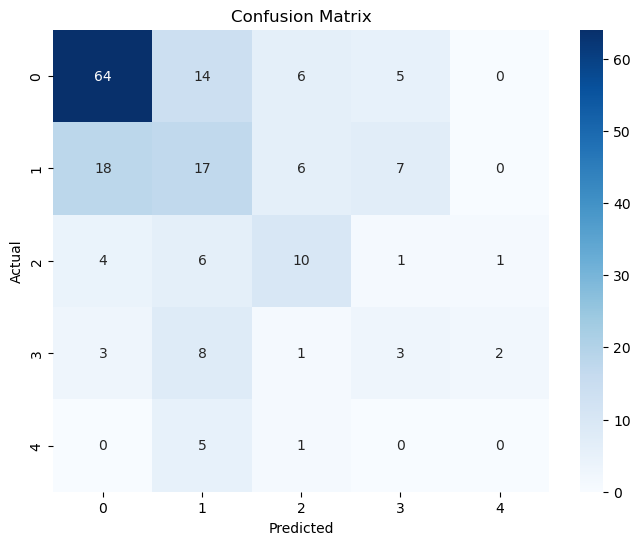

In [28]:
# Confusion Matrix Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.72      0.72        89
           1       0.34      0.35      0.35        48
           2       0.42      0.45      0.43        22
           3       0.19      0.18      0.18        17
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.33      0.34      0.34       182
weighted avg       0.51      0.52      0.51       182



In [30]:
# Precision Score

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision :", round(precision,4))

Precision : 0.5092


In [31]:
# Recall Score

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Recall :", round(recall,4))

Recall : 0.5165


In [32]:
# F1 Score

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("F1 Score :", round(f1,4))

F1 Score : 0.5127


# ROC-AUC Score

ROC-AUC (Receiver Operating Characteristic - Area Under Curve) is used to evaluate the classification model's ability to distinguish between different classes.

A higher ROC-AUC score indicates better model performance.

In [33]:
from sklearn.metrics import roc_auc_score

In [34]:
# ROC AUC Score

y_prob = dt_model.predict_proba(X_test_scaled)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr'
)

print("ROC AUC Score :", round(roc_auc,4))

ROC AUC Score : 0.6006


# Decision Tree Visualization

Visualizing the Decision Tree helps understand how the model makes decisions.

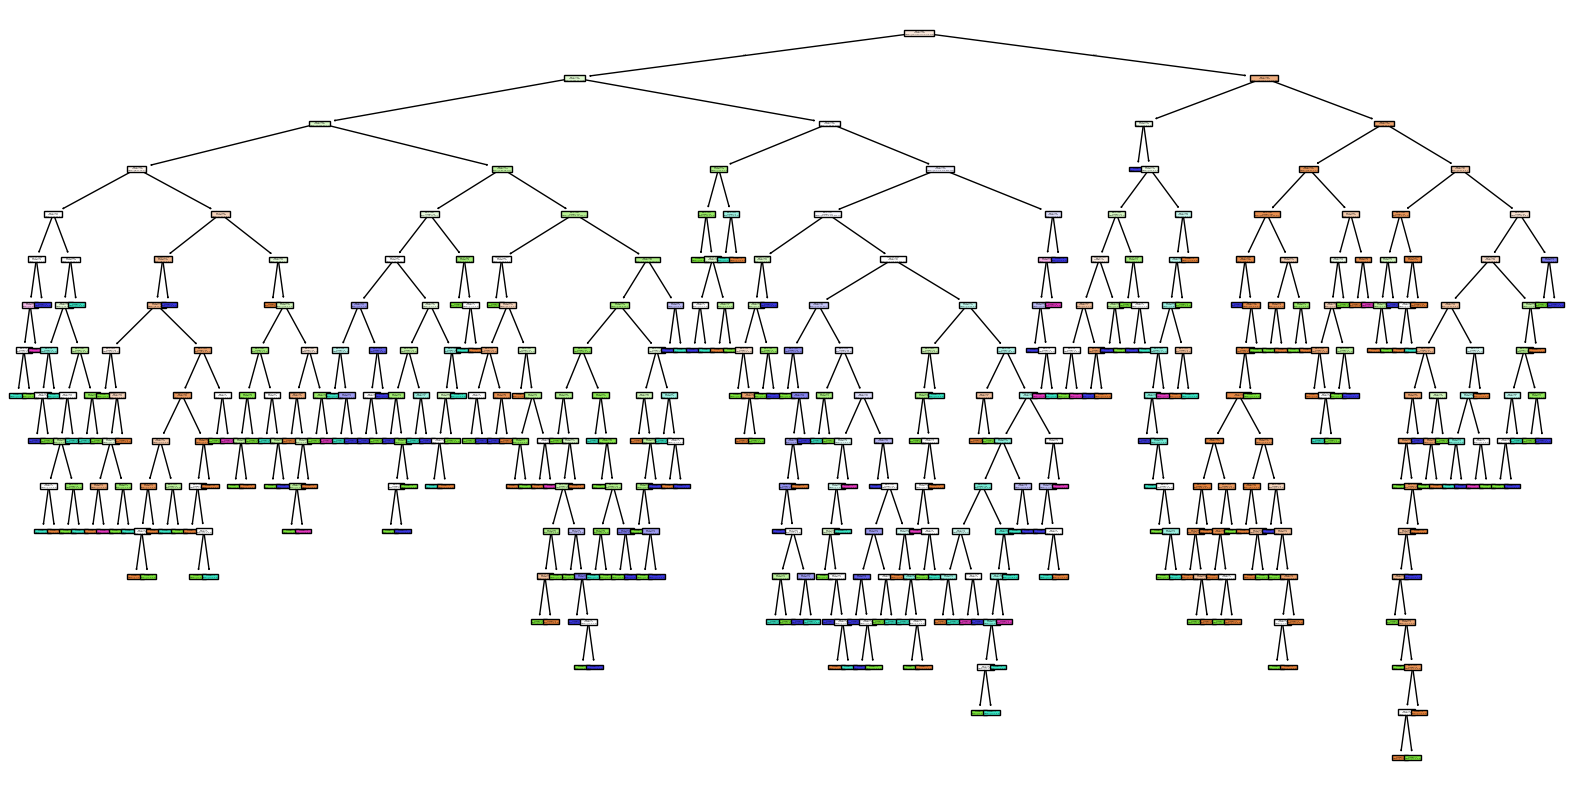

In [35]:
# Visualize Decision Tree

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    filled=True
)

plt.show()

# Hyperparameter Tuning

GridSearchCV is used to find the best Decision Tree parameters.

In [36]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [37]:
# Parameter Grid

param_grid = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10]
}

In [38]:
# Grid Search

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5
)

grid.fit(X_train_scaled, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [39]:
# Best Parameters

print("Best Parameters :")
print(grid.best_params_)

Best Parameters :
{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [40]:
# Best Cross Validation Score

print("Best Score :")
print(round(grid.best_score_,4))

Best Score :
0.5303


In [41]:
# Best Model

best_model = grid.best_estimator_

best_predictions = best_model.predict(X_test_scaled)

In [42]:
# Accuracy of Optimized Model

optimized_accuracy = accuracy_score(
    y_test,
    best_predictions
)

print("Optimized Accuracy :",
      round(optimized_accuracy,4))

Optimized Accuracy : 0.5714


# Conclusion

A Decision Tree Classification model was successfully developed to predict heart disease using patient health information.

The dataset was explored using Exploratory Data Analysis (EDA), missing values were handled, and categorical variables were encoded using Label Encoding.

Feature Scaling was performed using StandardScaler. The Decision Tree model was trained and evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC metrics.

Hyperparameter tuning was performed using GridSearchCV to improve model performance.

The final model demonstrated good classification capability and can be effectively used for heart disease prediction.

# Interview Question 1

## What are some common hyperparameters of Decision Tree models, and how do they affect performance?

### Answer

Some important Decision Tree hyperparameters are:

1. **max_depth**
   - Controls the maximum depth of the tree.
   - Higher depth may lead to overfitting.

2. **min_samples_split**
   - Minimum number of samples required to split a node.
   - Larger values reduce overfitting.

3. **min_samples_leaf**
   - Minimum number of samples required at a leaf node.
   - Helps create more generalized trees.

4. **criterion**
   - Used to measure the quality of a split.
   - Common options are:
     - Gini Index
     - Entropy

5. **max_features**
   - Specifies the number of features considered for splitting.
   - Helps control model complexity.

# Interview Question 2

## What is the difference between Label Encoding and One-Hot Encoding?

### Answer

| Label Encoding | One-Hot Encoding |
|---------------|------------------|
| Converts categories into numerical labels | Creates separate binary columns for each category |
| Uses a single column | Creates multiple columns |
| Suitable for ordinal data | Suitable for nominal data |
| Memory efficient | May increase dimensionality |

### Example

Suppose we have a column:

Color = [Red, Green, Blue]

#### Label Encoding

Red = 0

Green = 1

Blue = 2

#### One-Hot Encoding

| Red | Green | Blue |
|------|------|------|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |